In [1]:
# Wolfram Language Imports
from wolframclient.evaluation import WolframLanguageSession
from wolframclient.language import wl, wlexpr
ws = WolframLanguageSession()

In [40]:
# Display Latex
from IPython.display import display, Math

# Display Plots
%matplotlib notebook
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [66]:
def print_tex(expr):
    """Prints an expression in latex"""
    display(Math(expr))

def print_wlresult(expr):
    """Prints a wolfram language result in latex"""
    tex_expr = ws.evaluate(wl.ToString(wl.TeXForm(expr)))
    display(Math(tex_expr))

def print_wlexpr(expr):
    """Prints a wolfram language expression in latex"""
    tex_expr = ws.evaluate(wl.ToString(wl.TeXForm(ws.evaluate(expr))))
    display(Math(tex_expr))
    
def wc(expr):
    """Evaluates an expression, stores, and prints the result"""
    result = ws.evaluate(expr)
    save_expr_str = 'rrr = {}'.format(expr)
    ws.evaluate(save_expr_str)
    print_wlresult(ws.evaluate('rrr'))
    return result

def wplot(filename, command):
    export_expr = 'Export["{}", {}]'.format(filename, command)
    wc(export_expr)
    img = mpimg.imread(filename)
    imgplot = plt.imshow(img)
    plt.show()
    plt.axis('off')
    

print('\nPrinting latex:')
print_tex('\sum_{i=1}^{10} x_i')

print('\nPrinting the result of an evaluated expression:')
print_wlresult(ws.evaluate('x+2+y+3'))

print('\nEvaluating and printing an expression directly:')
print_wlexpr('Sum[x^k, {k, 0, 5}]')

print('\nEvaluating, storing, and printing reults:')
wc('Sum[x^k, {k, 0, 5}]')

print('\nAccessing those results in the variable "rrr":')
wc('rrr*10 + y')


Printing latex:


<IPython.core.display.Math object>


Printing the result of an evaluated expression:


<IPython.core.display.Math object>


Evaluating and printing an expression directly:


...


Evaluating, storing, and printing reults:


<IPython.core.display.Math object>


Accessing those results in the variable "rrr":


<IPython.core.display.Math object>

Plus[0.0, Times[10, Plus[1, Global`x, << 2 >>, Power[Global`x, 4], Power[Global`x, 5]]]]

In [18]:
wc('ClearAll[v,T]')
#calc('''
#N[LerchPhi[Exp[Pi*T], 1.0, 0.5 + I*v/Pi]]
#''')
calc('''
FullSimplify[1/Gamma[1/2 + I*v/Pi]*MeijerG[{{0, 1 - (1/2 + I*v/Pi)}, {}}, {{0, 0}, {}}, 1 - Exp[Pi*T]]]
''')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Plus[Times[2, Power[Plus[-1, Power[E, Times[Pi, Global`T]]], -1], << 1 >>, Power[Plus[Pi, Times[Complex[0, -2], Global`v]], -1], Hypergeometric2F1[1, 1, Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Power[Plus[1, Times[-1, Power[E, Times[Pi, Global`T]]]], -1]]], Times[Power[Times[-1, Power[E, Times[Pi, Global`T]]], Plus[Rational[-1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]], Pi, Sech[Global`v]]]

In [19]:
wc('''
FullSimplify[1/Gamma[1/2 - I*v/Pi]*MeijerG[{{0, 1 - (1/2 - I*v/Pi)}, {}}, {{0, 0}, {}}, 1 - Exp[Pi*T]]]
''')

<IPython.core.display.Math object>

Plus[Times[2, Power[Plus[-1, Power[E, Times[Pi, Global`T]]], -1], << 1 >>, Power[Plus[Pi, Times[Complex[0, 2], Global`v]], -1], Hypergeometric2F1[1, 1, Plus[Rational[3, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]], Power[Plus[1, Times[-1, Power[E, Times[Pi, Global`T]]]], -1]]], Times[Power[Times[-1, Power[E, Times[Pi, Global`T]]], Plus[Rational[-1, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]]], Pi, Sech[Global`v]]]

In [20]:
wc('''
MeijerG[{{a1, a2}, {}}, {{b1, b2}, {}}, z]
''')

<IPython.core.display.Math object>

Times[Pi, Plus[Times[Power[Global`z, Global`b1], Csc[Times[Plus[Times[-1, Global`b1], Global`b2], Pi]], << 1 >>, Gamma[Plus[1, Times[-1, Global`a2], Global`b1]], Hypergeometric2F1Regularized[Plus[1, Times[-1, Global`a1], Global`b1], Plus[1, Times[-1, Global`a2], Global`b1], Plus[1, Global`b1, Times[-1, Global`b2]], Global`z]], Times[Power[Global`z, Global`b2], Csc[Times[Plus[Global`b1, Times[-1, Global`b2]], Pi]], << 1 >>, Gamma[Plus[1, Times[-1, Global`a2], Global`b2]], Hypergeometric2F1Regularized[Plus[1, Times[-1, Global`a1], Global`b2], Plus[1, Times[-1, Global`a2], Global`b2], Plus[1, Times[-1, Global`b1], Global`b2], Global`z]]]]

In [21]:
wc('ClearAll[v, z]')
wc('b = 1/2 - I*v/Pi')
wc('''
FullSimplify[MeijerGReduce[Hypergeometric2F1[1, 1, b+1, Exp[Pi*T]]/b, v]]
''')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Times[2, Pi, Power[Plus[Pi, Times[Complex[0, -2], Global`v]], -1], Hypergeometric2F1[1, 1, Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Power[E, Times[Pi, Global`T]]]]

In [22]:
wc('''
FullSimplify[MeijerG[{{a1, a2, a3}, {}}, {{b1, b2, b3}, {}}, z]]
''')

<IPython.core.display.Math object>

MeijerG[((Global`a1, Global`a2, Global`a3), ()), ((Global`b1, Global`b2, Global`b3), ()), Global`z]

In [23]:
wc('''
FullSimplify[MeijerGReduce[
Exp[-I*T*v]/(v - I*Pi/2)*Hypergeometric2F1[1, 1, 3/2+I*v/Pi, 1/(1 - Exp[Pi*T])] \
- Exp[I*T*v]/(v + I*Pi/2)*Hypergeometric2F1[1, 1, 3/2-I*v/Pi, 1/(1 - Exp[Pi*T])],
v
]]
''')

<IPython.core.display.Math object>

Times[Complex[0, 2], Power[Pi, Rational[-1, 2]], Plus[Times[Power[Plus[Pi, Times[Complex[0, -2], Global`v]], -1], Hypergeometric2F1[1, 1, Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Power[Plus[1, Times[-1, Power[E, Times[Pi, Global`T]]]], -1]], Inactive[MeijerG][((), ()), ((0, Rational[1, 2]), ()), Times[Complex[0, Rational[-1, 2]], Global`T, Global`v], Rational[1, 2]]], Times[Power[Plus[Pi, Times[Complex[0, 2], Global`v]], -1], Hypergeometric2F1[1, 1, Plus[Rational[3, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]], Power[Plus[1, Times[-1, Power[E, Times[Pi, Global`T]]]], -1]], Inactive[MeijerG][((), ()), ((0, Rational[1, 2]), ()), Times[Complex[0, Rational[1, 2]], Global`T, Global`v], Rational[1, 2]]]]]

In [24]:
wc('''
Series[Hypergeometric2F1[1, 1, 3/2 + (I v)/Pi, (1 - E^(Pi T))^(-1)], {v, 0, 11}]
''')

<IPython.core.display.Math object>

SeriesData[Global`v, 0, << 2 >>, 12, 1]

In [ ]:
r[2]

In [25]:
wc('''
Derivative[0, 0, 1, 0][Hypergeometric2F1][1, 1, 3/2, 1/(1 - E^(Pi 1.0))] //N
''')

<IPython.core.display.Math object>

0.018967562122416664

In [26]:
wc('''
Series[Derivative[0, 0, 1, 0][Hypergeometric2F1][1, 1, 3/2, 1/(1 - E^(Pi 1.0))], {T, 0, 5} ]
''')

<IPython.core.display.Math object>

0.018967562122416664

In [27]:
wc('''
Hypergeometric2F1[1, 1, 3/2 - (I v)/Pi, 0] // N
''')

<IPython.core.display.Math object>

1.0

In [28]:
wc('''
Hypergeometric2F1[1, 1, x, 0] // N
''')

<IPython.core.display.Math object>

1.0

In [82]:
wc('''
FullSimplify[MeijerGReduce[Integrate[x^(2*M) * HypergeometricPFQ[{1}, {M+2, M+3/2}, -(x*v)^2/4 ], {x, 0, S}], v]]
''')

<IPython.core.display.Math object>

ConditionalExpression[Times[Rational[1, 2], Power[Global`S, Plus[1, Times[2, Global`M]]], << 1 >>, Gamma[Plus[2, Global`M]], Inactive[MeijerG][((0, Plus[Rational[1, 2], Times[-1, Global`M]]), ()), ((0,), (Plus[Rational[-1, 2], Times[-1, Global`M]], Plus[Rational[-1, 2], Times[-1, Global`M]], Plus[-1, Times[-1, Global`M]])), Times[Rational[1, 4], Power[Global`S, 2], Power[Global`v, 2]]]], And[Element[Times[Power[Global`S, 2], Power[Global`v, 2]], Reals], Greater[Plus[Global`M, Conjugate[Global`M]], -1]]]

In [83]:
wc('''
FullSimplify[Integrate[x^(2*M) * HypergeometricPFQ[{1}, {M+2, M+3/2}, -(x*v)^2/4 ], {x, 0, S}]]
''')

<IPython.core.display.Math object>

ConditionalExpression[Times[Power[Plus[1, Times[2, Global`M]], -1], Power[Global`S, Plus[1, Times[2, Global`M]]], HypergeometricPFQ[(1, Plus[Rational[1, 2], Global`M]), (Plus[Rational[3, 2], Global`M], Plus[Rational[3, 2], Global`M], Plus[2, Global`M]), Times[Rational[-1, 4], Power[Global`S, 2], Power[Global`v, 2]]]], And[Element[Times[Power[Global`S, 2], Power[Global`v, 2]], Reals], Greater[Re[Global`M], Rational[-1, 2]]]]

<IPython.core.display.Math object>

<IPython.core.display.Javascript object>


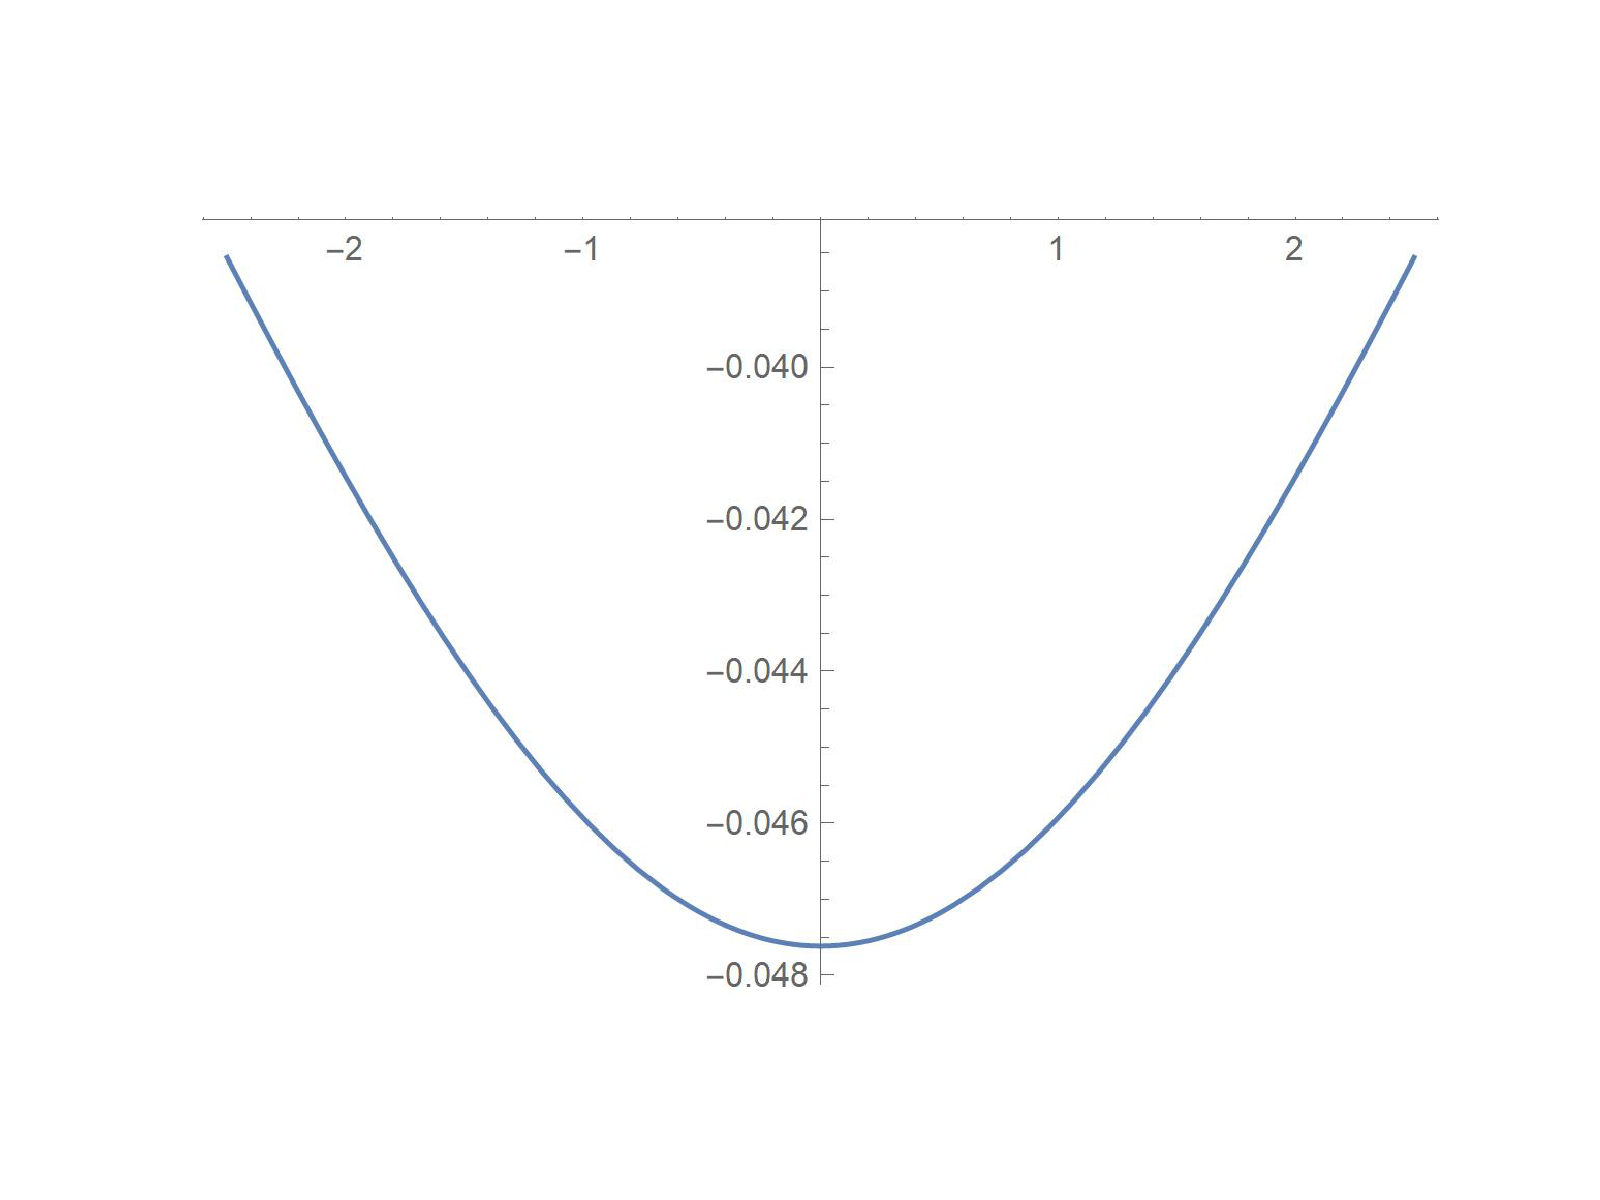

In [78]:
wplot("test.jpg", '''
Plot[
{-HypergeometricPFQ[{1, 10 + 1/2}, {10+3/2, 10 + 3/2, 10 + 2}, -1/4 * v^2 * 4.7^2] / (2*10+1)}
, {v, -2.5, 2.5}]
''')

# PlotRange -> {-0.1, 0.1}

In [94]:
wc('''
LaplaceTransform[x^(2*M+3) * Csch[Pi/2 * x], x, s]
''')

<IPython.core.display.Math object>

Times[2, Power[Pi, Times[-2, Plus[2, Global`M]]], Gamma[Plus[4, Times[2, Global`M]]], Zeta[Times[2, Plus[2, Global`M]], Plus[Rational[1, 2], Times[Power[Pi, -1], Global`s]]]]

In [95]:
wc('''
LaplaceTransform[HypergeometricPFQ[{1}, {M+2, M+5/2}, -(x*v)^2/4 ], x, s]
''')

<IPython.core.display.Math object>

Times[Power[Global`s, -1], HypergeometricPFQ[(Rational[1, 2], 1, 1), (Plus[2, Global`M], Plus[Rational[5, 2], Global`M]), Times[-1, Power[Global`s, -2], Power[Global`v, 2]]]]

In [96]:
wc('''
Convolve[
LaplaceTransform[x^(2*M+3) * Csch[Pi/2 * x], x, s],
LaplaceTransform[HypergeometricPFQ[{1}, {M+2, M+5/2}, -(x*v)^2/4 ], x, s],
s, y]
''')

<IPython.core.display.Math object>

Times[2, Power[Pi, Times[-2, Plus[2, Global`M]]], Convolve[Zeta[Times[2, Plus[2, Global`M]], Plus[Rational[1, 2], Times[Power[Pi, -1], Global`s]]], Times[Power[Global`s, -1], HypergeometricPFQ[(Rational[1, 2], 1, 1), (Plus[2, Global`M], Plus[Rational[5, 2], Global`M]), Times[-1, Power[Global`s, -2], Power[Global`v, 2]]]], Global`s, 0.0], Gamma[Plus[4, Times[2, Global`M]]]]

In [ ]:
ws.stop()